In [1]:
# PART (a): Load the CSV and inspect the first five rows
# Run the notebook from top to bottom. The written answers are in Report.md.

import numpy as np
import matplotlib.pyplot as plt

# Make the printed rows readable: five decimal places and no scientific notation.
# This only changes how numbers are displayed, not their stored values.
np.set_printoptions(precision=5, suppress=True, linewidth=120)

# Skip the header row and read the numerical columns into a 2D NumPy array.
# Each row is one house. The first column is an ID, not a model feature.
data = np.loadtxt("real+estate+valuation+data+set/Real estate valuation data set.csv", delimiter=",", skiprows=1)

# Python counts columns from zero: column 2 is age; the last column is price.
# x and y each contain one number per house. Price is in 10,000 NTD per ping.
x, y = data[:, 2], data[:, -1]

# Show the requested sample rows and row count, and count any NaN entries.
print(data[:5])
print("Rows:", len(data), "Missing values:", np.isnan(data).sum())

[[   1.      2012.917     32.        84.87882   10.        24.98298  121.54024   37.9    ]
 [   2.      2012.917     19.5      306.5947     9.        24.98034  121.53951   42.2    ]
 [   3.      2013.583     13.3      561.9845     5.        24.98746  121.54391   47.3    ]
 [   4.      2013.5       13.3      561.9845     5.        24.98746  121.54391   54.8    ]
 [   5.      2012.833      5.       390.5684     5.        24.97937  121.54245   43.1    ]]
Rows: 414 Missing values: 0


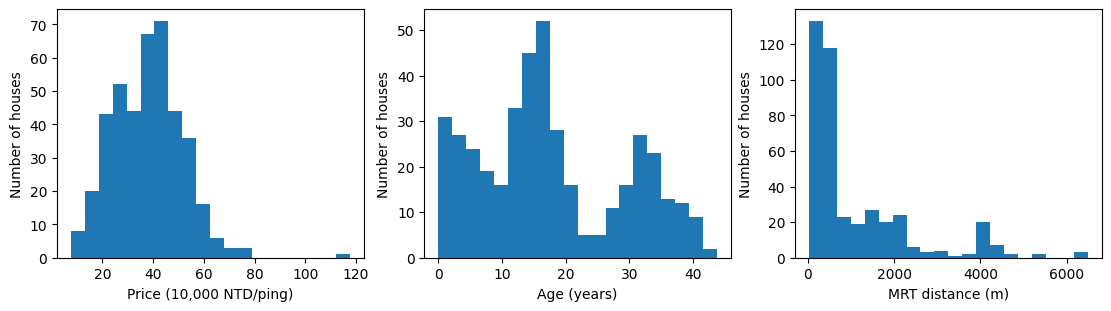

In [2]:
# PART (a): Histograms of price, house age, and MRT distance

# Create three side-by-side plots. Constrained layout keeps labels from overlapping.
fig, axes = plt.subplots(1, 3, figsize=(11, 3), layout="constrained")

# Match each plot to its CSV column and label: target (7), age (2), distance (3).
for ax, col, label in zip(axes, [7, 2, 3], ["Price (10,000 NTD/ping)", "Age (years)", "MRT distance (m)"]):
    # Divide the observed values into 20 bins and count houses in each bin.
    ax.hist(data[:, col], bins=20)
    ax.set(xlabel=label, ylabel="Number of houses")
plt.show()

In [ ]:
# PART (b): Fit price = w0 + w1 * age using gradient descent

# Start with a zero intercept and slope. Save the MSE to check convergence.
w0, w1 = 0.0, 0.0
age_loss = []

# Each epoch uses all houses to calculate one update; the learning rate is 0.002.
for _ in range(20_000):
    # Residual = predicted price - actual price, calculated at the current weights.
    error = w0 + w1 * x - y

    # Record the loss before this update. Entry 0 is the initial, untrained loss.
    age_loss.append(np.mean(error**2))

    # dL/dw0 = 2 * mean(error); dL/dw1 = 2 * mean(error * age).
    w0 -= 0.002 * 2 * error.mean()
    w1 -= 0.002 * 2 * np.mean(error * x)

# Recompute predictions after the final update and report the final MSE.
age_pred = w0 + w1 * x
print(f"w0 = {w0:.8f}, w1 = {w1:.8f}")
print(f"MSE = {np.mean((age_pred - y)**2):.8f}")

w0 = 42.43469704, w1 = -0.25148842
MSE = 176.50047403


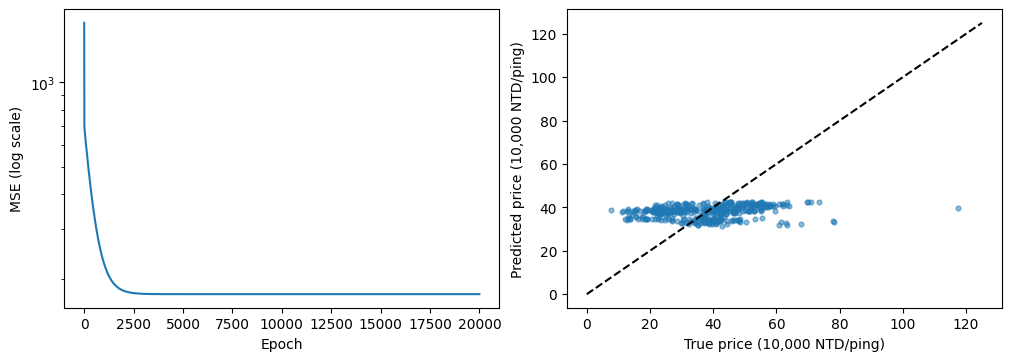

In [4]:
# PART (b): Plot convergence and predicted versus true price

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")

# The list index counts completed updates before each stored loss.
# A logarithmic vertical axis makes changes in the loss easier to see.
axes[0].semilogy(age_loss)
axes[0].set(xlabel="Epoch", ylabel="MSE (log scale)")

# Each dot is one house: actual price on x, model prediction on y.
# Small, partly transparent markers help show overlapping observations.
axes[1].scatter(y, age_pred, s=12, alpha=0.5)

# The dashed line is y = x, where a prediction would be exactly correct.
axes[1].plot([0, 125], [0, 125], "k--")
axes[1].set(xlabel="True price (10,000 NTD/ping)", ylabel="Predicted price (10,000 NTD/ping)")
plt.show()

In [5]:
# PART (c): Fit several features, first raw and then normalized

# X is a design matrix: one row per house and one column per coefficient.
# Its first column must contain ones for the intercept. This function works
# with any number of feature columns and starts a fresh fit on every call.
def fit(X, y, epochs, rate=0.05):
    w = np.zeros(X.shape[1])

    # Keep the initial weights as epoch 0. copy() saves an independent snapshot;
    # without it, later updates could change previously saved entries.
    history = [w.copy()]
    for _ in range(epochs):
        # @ is matrix multiplication: X @ w predicts the price of every house.
        error = X @ w - y

        # The MSE gradient is (2/n) * X.T @ error, where n = number of houses.
        # X.T pairs each feature column with the residuals. Subtracting rate
        # times this gradient updates all coefficients, including the intercept.
        w -= rate * (2 / len(y)) * (X.T @ error)
        history.append(w.copy())

    # Row k contains the weights after k updates, including the initial row.
    return np.array(history)

# Select age, MRT distance, and convenience-store count, in that order.
features = data[:, [2, 3, 4]]

# Add the constant column so the model can learn an intercept.
# Three updates are enough to show the raw run diverging, without overflow.
X_raw = np.column_stack((np.ones(len(y)), features))
raw_weights = fit(X_raw, y, 3)

# axis=0 calculates a separate mean and standard deviation for each feature.
# NumPy uses the population standard deviation by default (ddof=0).
# Standardize features only; leave the target and intercept column unchanged.
scaled = (features - features.mean(axis=0)) / features.std(axis=0)
X = np.column_stack((np.ones(len(y)), scaled))

# Use the same learning rate as the raw run, now for 600 updates.
# The last row of the returned history holds the final fitted coefficients.
weights = fit(X, y, 600)
multi_pred = X @ weights[-1]
print("Weights (intercept, age, distance, stores):", weights[-1])
print(f"MSE = {np.mean((multi_pred - y)**2):.8f}")

Weights (intercept, age, distance, stores): [37.98019 -2.87717 -6.78085  3.81708]
MSE = 84.76070642


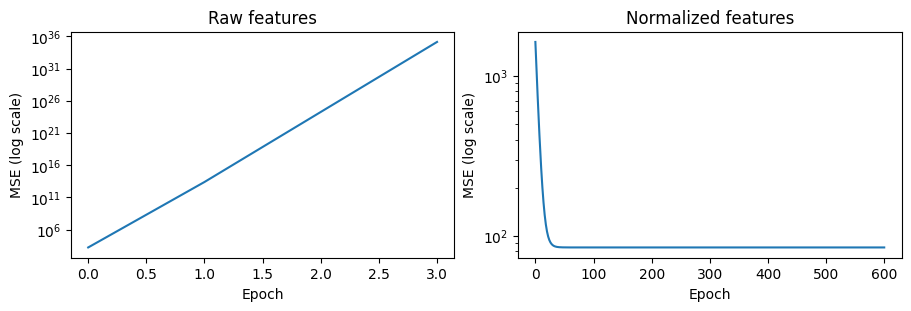

In [6]:
# PART (c): Compare the raw-feature and normalized-feature loss curves

# A weight history has shape (epochs + 1, number of coefficients).
# Multiplying X by the transposed weight history gives predictions for every
# house at every saved epoch: rows are houses and columns are epochs.
# y[:, None] changes y into a column so it is subtracted from every epoch.
# Squaring and averaging down the house rows (axis=0) gives one MSE per epoch.
raw_loss = np.mean((X_raw @ raw_weights.T - y[:, None])**2, axis=0)
scaled_loss = np.mean((X @ weights.T - y[:, None])**2, axis=0)

# Separate panels make both the short divergent run and the longer convergent
# run readable. Both vertical axes use logarithmic scales.
fig, axes = plt.subplots(1, 2, figsize=(9, 3), layout="constrained")
for ax, loss, title in zip(axes, [raw_loss, scaled_loss], ["Raw features", "Normalized features"]):
    ax.semilogy(loss)
    ax.set(title=title, xlabel="Epoch", ylabel="MSE (log scale)")
plt.show()

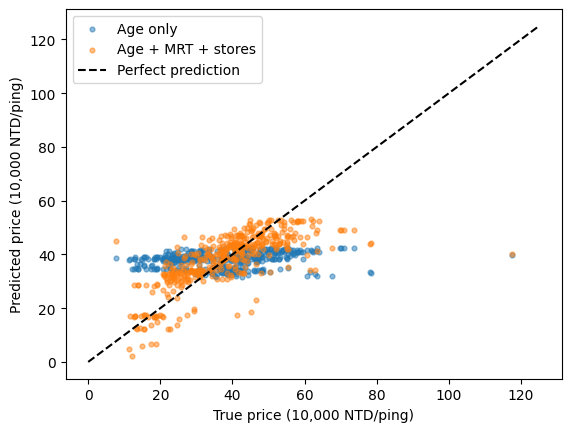

In [7]:
# PART (d): Compare both models on the same predicted-versus-true plot

# Each model predicts the same 414 houses, so the points can be compared
# directly. These are training-data predictions, not held-out test results.
plt.scatter(y, age_pred, s=12, alpha=0.5, label="Age only")
plt.scatter(y, multi_pred, s=12, alpha=0.5, label="Age + MRT + stores")

# Predictions on the dashed diagonal are correct; vertical distance from
# that line is the prediction error for a house.
plt.plot([0, 125], [0, 125], "k--", label="Perfect prediction")
plt.xlabel("True price (10,000 NTD/ping)")
plt.ylabel("Predicted price (10,000 NTD/ping)")
plt.legend()
plt.show()

In [8]:
# BONUS: Compare gradient descent with the normal-equation solution

# Setting the MSE gradient to zero gives (X.T @ X) @ w = X.T @ y.
# solve() solves this system directly instead of explicitly forming an inverse.
# Use the same normalized X as gradient descent so the coefficients match units.
best = np.linalg.solve(X.T @ X, X.T @ y)

# Subtract the closed-form coefficients from every saved gradient-descent row.
# axis=1 finds the largest absolute coefficient error within each epoch.
# An epoch passes only if EVERY coefficient is within 1e-6 of the solution.
close = np.max(np.abs(weights - best), axis=1) < 1e-6

print("Normal-equation weights:", best)
print(f"Normal-equation MSE: {np.mean((X @ best - y)**2):.8f}")
print("Largest coefficient difference:", np.max(np.abs(weights[-1] - best)))

# flatnonzero returns indices where close is True; [0] selects the first one.
# Because history includes the initial weights, its index is the epoch number.
print("First epoch within tolerance:", np.flatnonzero(close)[0])

Normal-equation weights: [37.98019 -2.87717 -6.78085  3.81708]
Normal-equation MSE: 84.76070642
Largest coefficient difference: 4.652900287283046e-11
First epoch within tolerance: 352
